In [1]:
# Import important library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

### Read the input file and check the data dimension

In [2]:
# You can access from v
#Read input file and understand the data
# "default" is my dependent variable
gc_df = pd.read_csv("german_credit.csv")

In [3]:
gc_df.head(2).T

,0,1
default,0,1
account_check_status,< 0 DM,0 <= ... < 200 DM
duration_in_month,6,48
credit_history,critical account/ other credits existing (not ...,existing credits paid back duly till now
purpose,domestic appliances,domestic appliances
credit_amount,1169,5951
savings,unknown/ no savings account,... < 100 DM
present_emp_since,.. >= 7 years,1 <= ... < 4 years
installment_as_income_perc,4,2
personal_status_sex,male : single,female : divorced/separated/married


In [4]:
gc_df.shape

(1000, 21)

### Q1 Randomly select 50% data for this use case( 1 Marks)
###### Hint: Use train_test_split

In [5]:
from sklearn.model_selection import train_test_split
X = gc_df.loc[:, gc_df.columns != 'default']
y = gc_df["default"]
test_size = 0.50 # taking 50:50 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
for i in range(50):
 X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)
print("Train_data ->", X_train, " " , "Test_data ->", y_test)

Train_data ->                                   account_check_status  duration_in_month  \
262                                             < 0 DM                 18   
457                                             < 0 DM                 12   
82                                 no checking account                 18   
563                                  0 <= ... < 200 DM                 36   
407                                             < 0 DM                 15   
452                                no checking account                 12   
464                                no checking account                 18   
961                                  0 <= ... < 200 DM                 21   
547                                no checking account                 24   
38   >= 200 DM / salary assignments for at least 1 ...                 10   
417                                             < 0 DM                 18   
163                                  0 <= ... < 200 DM        

In [6]:
gc_df.head(3).T

,0,1,2
default,0,1,0
account_check_status,< 0 DM,0 <= ... < 200 DM,no checking account
duration_in_month,6,48,12
credit_history,critical account/ other credits existing (not ...,existing credits paid back duly till now,critical account/ other credits existing (not ...
purpose,domestic appliances,domestic appliances,(vacation - does not exist?)
credit_amount,1169,5951,2096
savings,unknown/ no savings account,... < 100 DM,... < 100 DM
present_emp_since,.. >= 7 years,1 <= ... < 4 years,4 <= ... < 7 years
installment_as_income_perc,4,2,2
personal_status_sex,male : single,female : divorced/separated/married,male : single


In [7]:
# Lets build a Ensemble model but need to modify the dataset first


### Q2.Prepare the model data by converting non-numeric to dummy ( 1 Marks)
##### Hint: Use get_dummies

In [8]:
gc_df_dummies = pd.get_dummies( gc_df, columns = ['account_check_status','credit_history','purpose','savings','present_emp_since',
                                                   'personal_status_sex','other_debtors','property','other_installment_plans',
                                                    'housing','job','telephone','foreign_worker'],drop_first=True)
gc_df_dummies.head(2).T

,0,1
default,0,1
duration_in_month,6,48
credit_amount,1169,5951
installment_as_income_perc,4,2
present_res_since,4,2
age,67,22
credits_this_bank,2,1
people_under_maintenance,1,1
account_check_status_< 0 DM,1,0
account_check_status_>= 200 DM / salary assignments for at least 1 year,0,0


In [9]:
# Print Shape of model data
gc_df_dummies.shape

(1000, 49)

### Check for highly correlated variables but don't required any treatment for this use case

In [10]:
# Create correlation matrix
corr_matrix = gc_df_dummies.corr().abs()

# Select upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(np.bool))

# Find features with correlation greater than 0.7
to_corr = [column for column in upper.columns if any(upper[column] >= 0.7)]

print(to_corr)
print("other_debtors_none/other_debtors_guarantor  And housing_rent/housing_own have a strong Negative co-relation of less than -0.7")

['other_debtors_none', 'housing_rent']
other_debtors_none/other_debtors_guarantor  And housing_rent/housing_own have a strong Negative co-relation of less than -0.7


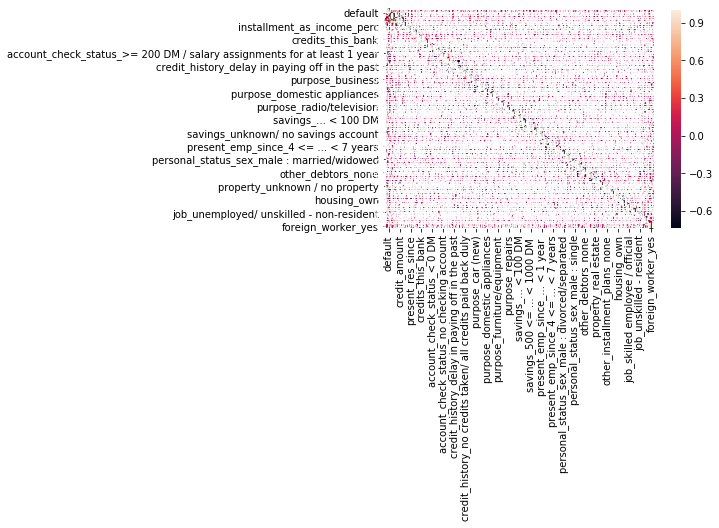

In [11]:
sns.heatmap( gc_df_dummies.corr(), annot=True)

### Drop the original variables which are converted to dummy

In [12]:
print("As in get_dummies I have used drop_first = True hence it drops the original categorical columns \n hence the below head function displays all the columns in 0 and 1 without showing categorical data ")
gc_df_dummies.head(2).T

As in get_dummies I have used drop_first = True hence it drops the original categorical columns 
 hence the below head function displays all the columns in 0 and 1 without showing categorical data 


,0,1
default,0,1
duration_in_month,6,48
credit_amount,1169,5951
installment_as_income_perc,4,2
present_res_since,4,2
age,67,22
credits_this_bank,2,1
people_under_maintenance,1,1
account_check_status_< 0 DM,1,0
account_check_status_>= 200 DM / salary assignments for at least 1 year,0,0


### Q3 Split Train/Test data 70:30 ratio( 1 Marks)
##### Hint:from sklearn.model_selection import train_test_split

In [13]:
gc_df_dummies.columns

Index(['default', 'duration_in_month', 'credit_amount',
       'installment_as_income_perc', 'present_res_since', 'age',
       'credits_this_bank', 'people_under_maintenance',
       'account_check_status_< 0 DM',
       'account_check_status_>= 200 DM / salary assignments for at least 1 year',
       'account_check_status_no checking account',
       'credit_history_critical account/ other credits existing (not at this bank)',
       'credit_history_delay in paying off in the past',
       'credit_history_existing credits paid back duly till now',
       'credit_history_no credits taken/ all credits paid back duly',
       'purpose_business', 'purpose_car (new)', 'purpose_car (used)',
       'purpose_domestic appliances', 'purpose_education',
       'purpose_furniture/equipment', 'purpose_radio/television',
       'purpose_repairs', 'purpose_retraining', 'savings_... < 100 DM',
       'savings_100 <= ... < 500 DM', 'savings_500 <= ... < 1000 DM ',
       'savings_unknown/ no savings 

In [18]:
from sklearn.preprocessing import StandardScaler
X = gc_df_dummies[['duration_in_month', 'credit_amount',
       'installment_as_income_perc', 'present_res_since', 'age',
       'credits_this_bank', 'people_under_maintenance',
       'account_check_status_< 0 DM',
       'account_check_status_>= 200 DM / salary assignments for at least 1 year',
       'account_check_status_no checking account',
       'credit_history_critical account/ other credits existing (not at this bank)',
       'credit_history_delay in paying off in the past',
       'credit_history_existing credits paid back duly till now',
       'credit_history_no credits taken/ all credits paid back duly',
       'purpose_business', 'purpose_car (new)', 'purpose_car (used)',
       'purpose_domestic appliances', 'purpose_education',
       'purpose_furniture/equipment', 'purpose_radio/television',
       'purpose_repairs', 'purpose_retraining', 'savings_... < 100 DM',
       'savings_100 <= ... < 500 DM', 'savings_500 <= ... < 1000 DM ',
       'savings_unknown/ no savings account',
       'present_emp_since_... < 1 year ',
       'present_emp_since_1 <= ... < 4 years',
       'present_emp_since_4 <= ... < 7 years', 'present_emp_since_unemployed',
       'personal_status_sex_male : divorced/separated',
       'personal_status_sex_male : married/widowed',
       'personal_status_sex_male : single', 'other_debtors_guarantor',
       'other_debtors_none',
       'property_if not A121/A122 : car or other, not in attribute 6',
       'property_real estate', 'property_unknown / no property',
       'other_installment_plans_none', 'other_installment_plans_stores',
       'housing_own', 'housing_rent', 'job_skilled employee / official',
       'job_unemployed/ unskilled - non-resident', 'job_unskilled - resident',
       'telephone_yes, registered under the customers name ',
       'foreign_worker_yes']]
Y = gc_df_dummies["default"]
test_size = 0.30 # taking 70:30 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X = StandardScaler().fit_transform(X)
train_set, test_set, train_labels, test_labels = train_test_split(X, Y, test_size=test_size, random_state=seed)

### Q4 Build Random Forest Model( 1 Marks)
#### Hint:from sklearn.ensemble import RandomForestClassifier using n_jobs=2,n_estimators=500,criterion="entropy",random_state=9999

In [31]:
from sklearn.ensemble import RandomForestClassifier
Rf_model = RandomForestClassifier(n_jobs=2,n_estimators=500,criterion='entropy',random_state=9999 )
Rf_model.fit(train_set, train_labels)
y_predict_Rf=Rf_model.predict(test_set)
y_predict_Rf

array([0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0], d

### Q5 Calculate Confusion Matrix and Accuracy score (1 Marks)
##### Hint: Use confusion_matrix and accuracy_score

In [16]:
#Confusion Metrics
from sklearn.metrics import confusion_matrix

conf_mat = confusion_matrix(test_labels, y_predict_Rf)
print("Confusion Metrics is :" ,conf_mat)

Confusion Metrics is : [[201  16]
 [ 47  36]]


In [25]:
#Accuracy Score
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
pscore = accuracy_score(test_labels, y_predict_Rf)
print("Accuracy Score is :" ,pscore)

Accuracy Score is : 0.79


### Q6 Show the list of the features importance( 1 Marks)

In [21]:
print (pd.Series(Rf_model.feature_importances_,index = list(X)).sort_values(ascending=False))

-0.745131   0.949817  -0.416562   1.634247   0.566664   2.050009  -0.154629   1.303197  -0.075233   0.695681  -0.700472   0.367466  -0.604063  -0.734498  -0.662192  -0.705079  -0.300305   1.701591   3.299067   0.056265  -0.403094  -0.221264  -0.365168  -0.520060  -0.426132  -0.672471  -1.008483  -1.014508  -0.303495   1.263499  -0.481426   0.265387   0.919689  -0.711459  -0.637026   0.522713   1.006173  -0.415145  -0.725283  -0.997141  -0.332559  -0.749030   1.039491   1.033465   1.017870  -0.665736  -0.344610  -0.680268   1.402441  -0.424715  -0.332559   0.954779  -0.712168   0.037834  -0.370839  -0.881947   1.133064   2.231130  -0.464412   1.048352  -0.666445  -0.614696  -0.467248   3.951952  -0.031991   0.680085  -0.389979  -0.802551  -0.514743  -0.310938   1.723212  -0.900732  -0.746904   0.950880  -0.458741  -0.618595   0.245892   0.531574   2.185052   0.198751   0.946981  -0.729536  -0.603709  -0.537428  -0.338939  -0.659002  -0.700472   3.310764  -0.362333  -0.766752  -0.940430 

### Q7 K-fold cross-validation( 2 Marks)
##### k-fold cross validation( without stratification)
##### Usually k is set as 10-20 in practical settings, depends on data set size

In [26]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

In [27]:
# Use below values
num_folds = 10
seed = 77
models = []
models.append(('RandomForest', Rf_model))

In [ ]:
#Validate the Random Forest model build above using k fold

In [28]:
from sklearn import model_selection
from sklearn.metrics import make_scorer,accuracy_score,precision_score,recall_score,f1_score
scoring = {'accuracy' : make_scorer(accuracy_score), 
           'precision' : make_scorer(precision_score),
           'recall' : make_scorer(recall_score), 
           'f1_score' : make_scorer(f1_score)}
for name, model in models:
	kfold = model_selection.KFold(n_splits=num_folds,random_state=seed)
	cv_results = results = model_selection.cross_validate(estimator=model,
                                          X=X,
                                          y=y,
                                          cv=kfold,
                                          scoring=scoring)
	cv_results

In [29]:
cv_results

{'fit_time': array([3.43227768, 1.02541256, 0.96241355, 0.94946671, 0.92443514,
        0.91346526, 1.1203537 , 1.35421968, 0.92489672, 0.92846727]),
 'score_time': array([0.85228109, 0.82267118, 0.92545295, 0.82137275, 0.92354345,
        0.82333517, 0.82006502, 0.9211731 , 0.82285953, 0.92521286]),
 'test_accuracy': array([0.87, 0.66, 0.78, 0.81, 0.8 , 0.68, 0.74, 0.78, 0.75, 0.74]),
 'train_accuracy': array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]),
 'test_precision': array([0.8       , 0.44444444, 0.52380952, 0.68      , 0.9       ,
        0.84615385, 0.64285714, 0.8125    , 0.61111111, 0.66666667]),
 'train_precision': array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]),
 'test_recall': array([0.64      , 0.25      , 0.47826087, 0.60714286, 0.32142857,
        0.26829268, 0.3       , 0.40625   , 0.37931034, 0.375     ]),
 'train_recall': array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]),
 'test_f1_score': array([0.71111111, 0.32      , 0.5       , 0.64150943, 0.47368421,
        0.4074

In [32]:
print("the Mean Accuracy Score after KFold is :", cv_results["test_accuracy"].mean())

the Mean Accuracy Score after KFold is : 0.761


In [ ]:
# Calculate score standard deviation using std()

In [33]:
print("the Mean std Score after KFold is :", cv_results["test_accuracy"].std())

the Mean std Score after KFold is : 0.05855766388782941


# Q8 Print the confusion matrix( 1 Marks)

In [35]:
kf=KFold(n_splits=num_folds,shuffle=True,random_state=seed)
for model, name in zip([Rf_model], ['RF']):
  for train,test in kf.split(X,y):
        Xtrain,Xtest=X[train,:],X[test,:]
        Ytrain,Ytest=Y[train],Y[test]
        model.fit(Xtrain,Ytrain)
        Y_predict=model.predict(Xtest)
        cm=confusion_matrix(Ytest,Y_predict)
        print(cm)

[[71  0]
 [11 18]]
[[67  4]
 [16 13]]
[[66  6]
 [26  2]]
[[74  4]
 [17  5]]
[[62  5]
 [25  8]]
[[60  6]
 [20 14]]
[[62  5]
 [20 13]]
[[63  6]
 [21 10]]
[[63  6]
 [20 11]]
[[66  4]
 [16 14]]


# Q9.Classification accuracy: 
percentage of correct predictions and Calculate sensitivity (or True Positive Rate or Recall) and Precision.
( 1 Marks)

In [36]:
precision_scores = []
recall_scores = []
for train,test in kf.split(X,Y):
   Xtrain,Xtest=X[train,:],X[test,:]
   Ytrain,Ytest=Y[train],Y[test]
   model.fit(Xtrain,Ytrain)
   Y_predict=model.predict(Xtest)
   precision_scores.append(precision_score(Ytest,Y_predict, average='micro'))
   recall_scores.append(recall_score(Ytest,Y_predict, average='micro'))

print(precision_scores)
print("precision: %0.2f (+/- %0.2f)" % (np.mean(precision_scores), np.std(precision_scores) *2 ))
print(recall_scores)
print("Recall: %0.2f (+/- %0.2f)" % (np.mean(recall_scores), np.std(recall_scores) * 2))

[0.89, 0.8, 0.68, 0.79, 0.7, 0.74, 0.75, 0.73, 0.74, 0.8]
precision: 0.76 (+/- 0.11)
[0.89, 0.8, 0.68, 0.79, 0.7, 0.74, 0.75, 0.73, 0.74, 0.8]
Recall: 0.76 (+/- 0.11)


In [38]:
from sklearn.model_selection import KFold
kf=KFold(n_splits=10,shuffle=True,random_state=77)
for model, name in zip([Rf_model], ['RF']):
    k=0
    recall=np.zeros((2,10))
    prec=np.zeros((2,10))
    fscore=np.zeros((2,10))
    for train,test in kf.split(X,Y):
        Xtrain,Xtest=X[train,:],X[test,:]
        Ytrain,Ytest=Y[train],Y[test]
        model.fit(Xtrain,Ytrain)
        Y_predict=model.predict(Xtest)
        cm=confusion_matrix(Ytest,Y_predict)
        for i in np.arange(0,2):
            recall[i,k]=cm[i,i]/cm[i,:].sum()
        for i in np.arange(0,2):
            prec[i,k]=cm[i,i]/cm[:,i].sum()
        k=k+1
    print("Wt Recall For 0 is :",np.mean(recall[0,:]))
    print("Wt Recall For 1 is :",np.mean(recall[1,:]))
    print("Wt precision For 0 is :",np.mean(prec[0,:]))
    print("Wt precision For 1 is :",np.mean(prec[1,:]))

Wt Recall For 0 is : 0.933782786434211
Wt Recall For 1 is : 0.3559881179694044
Wt precision For 0 is : 0.7736316124229206
Wt precision For 1 is : 0.6657704876822523


# Q10.Plot Receiver Operating Characteristic (ROC) Curves( 1 Marks)

In [ ]:
#Hint: Use roc_curve

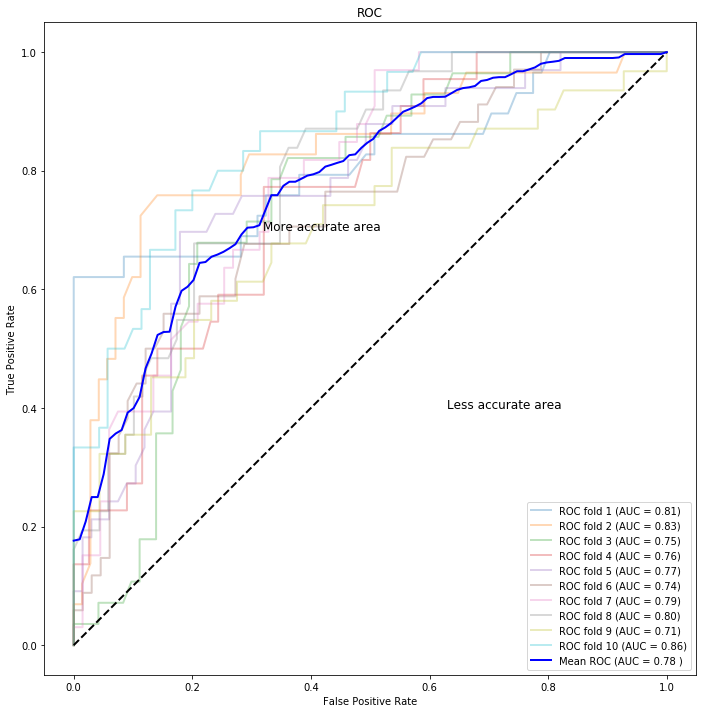

In [42]:
from sklearn.metrics import roc_curve,auc
fig1 = plt.figure(figsize=[12,12])
ax1 = fig1.add_subplot(111,aspect = 'equal')
tprs = []
aucs = []
mean_fpr = np.linspace(0,1,100)
i = 1
for train,test in kf.split(X,Y):
    Xtrain,Xtest=X[train,:],X[test,:]
    Ytrain,Ytest=Y[train],Y[test]
    prediction = Rf_model.fit(Xtrain,Ytrain).predict_proba(Xtest)
    fpr, tpr, t = roc_curve(Ytest, prediction[:, 1])
    tprs.append(np.interp(mean_fpr, fpr, tpr))
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    plt.plot(fpr, tpr, lw=2, alpha=0.3, label='ROC fold %d (AUC = %0.2f)' % (i, roc_auc))
    i= i+1

plt.plot([0,1],[0,1],linestyle = '--',lw = 2,color = 'black')
mean_tpr = np.mean(tprs, axis=0)
mean_auc = auc(mean_fpr, mean_tpr)
plt.plot(mean_fpr, mean_tpr, color='blue',
         label=r'Mean ROC (AUC = %0.2f )' % (mean_auc),lw=2, alpha=1)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC')
plt.legend(loc="lower right")
plt.text(0.32,0.7,'More accurate area',fontsize = 12)
plt.text(0.63,0.4,'Less accurate area',fontsize = 12)
plt.show()

ROC curve can help you to choose a threshold that balances sensitivity and specificity in a way that makes sense for your particular context

# Q11. Calculate AUC(the percentage of the ROC plot that is underneath the curve) - optional

In [43]:
roc_auc=[]
for train,test in kf.split(X,Y):
        Xtrain,Xtest=X[train,:],X[test,:]
        Ytrain,Ytest=Y[train],Y[test]
        Rf_model.fit(Xtrain,Ytrain)
        Y_predict=model.predict(Xtest)
        cm=confusion_matrix(Ytest,Y_predict)
        fpr,tpr, _ = roc_curve(Ytest,Y_predict)
        roc_auc.append(auc(fpr, tpr))
print("AUC scores: %0.02f (+/- %0.5f) [%s]" % (np.mean(roc_auc), np.var(roc_auc,ddof=1), name ))

AUC scores: 0.64 (+/- 0.00718) [RF]


### Bootstrapping ( Bonus)
##### Given a dataset of size n, a bootstrap sample is created by sampling n instances uniformly from the data (with/without replacement)
##### Create a model with each bootstrap sample and validate it with the test set
##### Final result is calculated by averaging the accuracy of models

In [ ]:
data = [10,20,30,40,50,60,70,80,90,100]
n_size = int(len(data) * .5) 
n_size
train = resample(data, n_samples=n_size)  # Sampling with replacement 
test = np.array([x for x in data if x not in train])
print("Train_data ->", train, " " , "Test_data ->", test)

In [ ]:
from sklearn.utils import resample
import numpy as np
from sklearn.ensemble import RandomForestClassifier
# load dataset
data = [10,20,30,40,50,60,70,80,90,100]   # original data with 10 data points
# configure bootstrap
n_iterations = 10              # picking only 50 % of the given data in every bootstrap sample
n_size = int(len(data) * .5)    # Number of bootstrap samples to create = 10
# run bootstrap
stats = list()
for i in range(n_iterations):
    # prepare train and test sets
    train = resample(data, n_samples=n_size)  # Sampling with replacement 
    test = np.array([x for x in data if x not in train])
    print("Train_data ->", train, " " , "Test_data ->", test)
    model = RandomForestClassifier()
    model.fit(train)
    predictions = model.predict(test) 
    score = accuracy_score(test[:,-1], predictions)
    print(score)
    stats.append(score)


In [ ]:
from sklearn.utils import resample
from sklearn.metrics import accuracy_score

for i in range(bootstrap_iteration):
    X_, y_ = resample(X_train, y_train)
    rfm.fit(X_, y_)
    y_pred = rfm.predict(X_test)
    
    acc = accuracy_score(y_pred, y_test)
    accuracy.append(acc)

In [ ]:
accuracy = np.array(accuracy)
print('Accuracy Score')
print('Avearge: ', accuracy.mean())
print('Standard deviation: ', accuracy.std())